<a href="https://colab.research.google.com/github/Amanyadav7779913/UAPOML/blob/main/UAPOML_ASS_2_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QUESTION 1

Part a

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

prices_df = pd.DataFrame({
    'RELIANCE': [2800, 2850, 2830, 2900, 2880, 2950],
    'INFY': [1450, 1470, 1460, 1490, 1510, 1500],
    'HDFCBANK': [1600, 1580, 1610, 1625, 1615, 1640],
    'TATAMOTORS': [520, 535, 528, 540, 555, 548]
}, index=['Day1', 'Day2', 'Day3', 'Day4', 'Day5', 'Day6'])

returns_df = prices_df.pct_change()

print("Returns Matrix:")
print(returns_df)

Returns Matrix:
      RELIANCE      INFY  HDFCBANK  TATAMOTORS
Day1       NaN       NaN       NaN         NaN
Day2  0.017857  0.013793 -0.012500    0.028846
Day3 -0.007018 -0.006803  0.018987   -0.013084
Day4  0.024735  0.020548  0.009317    0.022727
Day5 -0.006897  0.013423 -0.006154    0.027778
Day6  0.024306 -0.006623  0.015480   -0.012613


Part b

Units Purchased:
RELIANCE       89.285714
INFY          172.413793
HDFCBANK      156.250000
TATAMOTORS    480.769231
Name: Day1, dtype: float64

Portfolio Value:
Day1    1.000000e+06
Day2    1.011999e+06
Day3    1.009811e+06
Day4    1.029347e+06
Day5    1.036658e+06
Day6    1.041725e+06
dtype: float64


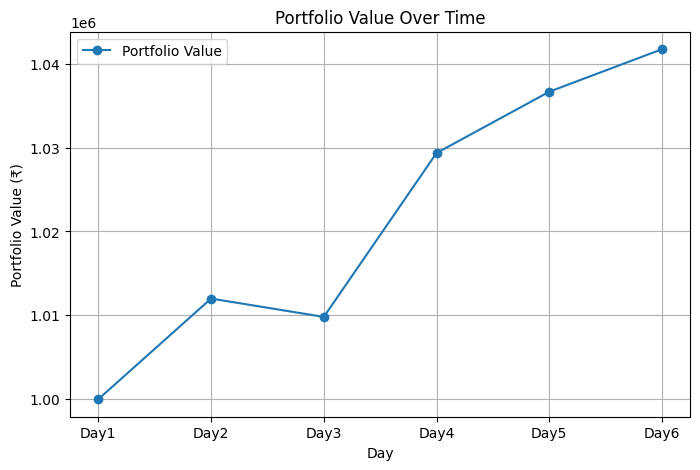

In [ ]:
investment = 1000000
weights = np.array([0.25, 0.25, 0.25, 0.25])

capital_per_asset = investment * weights

units = capital_per_asset / prices_df.iloc[0]

print("Units Purchased:")
print(units)

# Vectorized portfolio value calculation
portfolio_value = prices_df.dot(units)

print("\nPortfolio Value:")
print(portfolio_value)

# Plot
plt.figure(figsize=(8,5))
plt.plot(portfolio_value.index,
         portfolio_value.values,
         marker='o',
         label='Portfolio Value')

plt.title("Portfolio Value Over Time")
plt.xlabel("Day")
plt.ylabel("Portfolio Value (₹)")
plt.legend()
plt.grid(True)
plt.show()

Part c

In [ ]:
portfolio_returns = portfolio_value.pct_change().dropna()

daily_volatility = portfolio_returns.std()

annualized_volatility = daily_volatility * np.sqrt(252)

print("Daily Volatility:", daily_volatility)
print("Annualized Volatility:", annualized_volatility)

Daily Volatility: 0.008034199876278432
Annualized Volatility: 0.12753896913611182


# Q2

Part a

In [ ]:
import numpy as np

# Generate synthetic returns
np.random.seed(42)
returns = np.random.normal(loc=0.001, scale=0.015, size=50)

# Historical VaR
VaR_95 = -np.percentile(returns, 5)
VaR_99 = -np.percentile(returns, 1)

print("VaR (95%):", f"{VaR_95:.4%}")
print("VaR (99%):", f"{VaR_99:.4%}")

print("\nInterpretation:")
print(
    f"95% VaR = {VaR_95:.2%}. "
    f"There is only a 5% chance that the portfolio will lose more than "
    f"{VaR_95:.2%} in a single day."
)

print(
    f"99% VaR = {VaR_99:.2%}. "
    f"There is only a 1% chance that the portfolio will lose more than "
    f"{VaR_99:.2%} in a single day."
)

VaR (95%): 2.5188%
VaR (99%): 2.8054%

Interpretation:
95% VaR = 2.52%. There is only a 5% chance that the portfolio will lose more than 2.52% in a single day.
99% VaR = 2.81%. There is only a 1% chance that the portfolio will lose more than 2.81% in a single day.


Part b

In [ ]:
# CVaR Calculation

threshold_95 = np.percentile(returns, 5)
threshold_99 = np.percentile(returns, 1)

CVaR_95 = -returns[returns <= threshold_95].mean()
CVaR_99 = -returns[returns <= threshold_99].mean()

print("CVaR (95%):", f"{CVaR_95:.4%}")
print("CVaR (99%):", f"{CVaR_99:.4%}")

print("\nWhy is CVaR more informative than VaR?")
print(
    "CVaR measures the average loss beyond the VaR threshold. "
    "While VaR only tells us the minimum loss expected at a confidence level, "
    "CVaR captures the severity of extreme losses. "
    "Therefore, CVaR provides a better measure of tail risk."
)

CVaR (95%): 2.7180%
CVaR (99%): 2.8395%

Why is CVaR more informative than VaR?
CVaR measures the average loss beyond the VaR threshold. While VaR only tells us the minimum loss expected at a confidence level, CVaR captures the severity of extreme losses. Therefore, CVaR provides a better measure of tail risk.


Part c

Maximum Drawdown: 18.1649%
The portfolio experienced a maximum decline of 18.16% from its peak value before recovering.


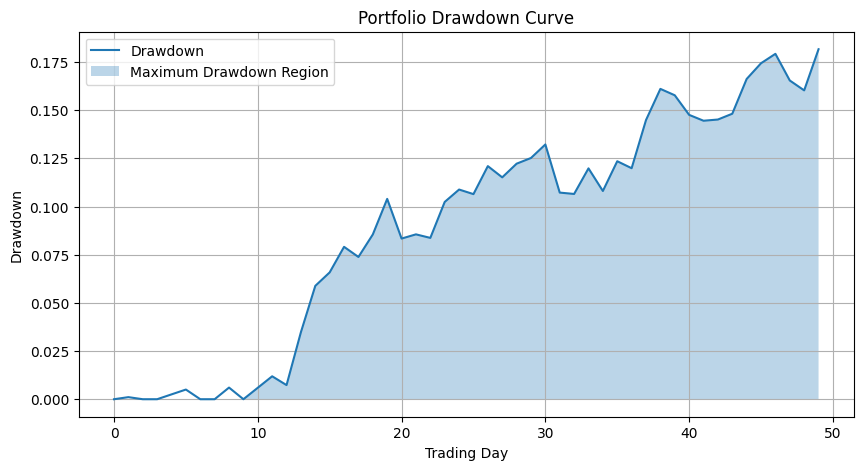

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Simulate portfolio value path
initial_value = 1000000

portfolio_value = initial_value * np.cumprod(1 + returns)
portfolio_value = pd.Series(portfolio_value)

# Running Peak
running_peak = portfolio_value.cummax()

# Drawdown
drawdown = (running_peak - portfolio_value) / running_peak

# Maximum Drawdown
max_dd = drawdown.max()

print("Maximum Drawdown:", f"{max_dd:.4%}")

print(
    f"The portfolio experienced a maximum decline of "
    f"{max_dd:.2%} from its peak value before recovering."
)

# Peak and Trough of Maximum Drawdown
trough_idx = drawdown.idxmax()
peak_idx = portfolio_value[:trough_idx + 1].idxmax()

# Plot Drawdown Curve
plt.figure(figsize=(10,5))

plt.plot(drawdown.index,
         drawdown,
         label='Drawdown')

plt.fill_between(
    drawdown.index,
    drawdown,
    where=(drawdown.index >= peak_idx) &
          (drawdown.index <= trough_idx),
    alpha=0.3,
    label='Maximum Drawdown Region'
)

plt.title("Portfolio Drawdown Curve")
plt.xlabel("Trading Day")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)

plt.show()

VaR: Value at Risk estimates the maximum expected loss over a specified time horizon at a given confidence level. A 95% VaR means there is only a 5% chance of observing a loss larger than the reported value.

CVaR: Conditional Value at Risk measures the average loss when losses exceed the VaR threshold. It is more informative because it captures the magnitude of extreme losses and provides a better assessment of tail risk.

Maximum Drawdown: Maximum Drawdown represents the largest percentage decline from a portfolio's peak value to its subsequent trough and is commonly used to assess downside risk.

# Q3

Part a

In [ ]:
import numpy as np

# Generate 252 days of synthetic portfolio returns

np.random.seed(42)

returns = np.random.normal(
    loc=0.001,
    scale=0.015,
    size=252
)

# Risk-free rate
rf_annual = 0.06

# Annualized portfolio return
annual_return = np.mean(returns) * 252

# Annualized volatility
annual_volatility = np.std(returns, ddof=1) * np.sqrt(252)

# Sharpe Ratio
sharpe_ratio = (annual_return - rf_annual) / annual_volatility

print("Annualized Return:", f"{annual_return:.4%}")
print("Annualized Volatility:", f"{annual_volatility:.4%}")
print("Sharpe Ratio:", round(sharpe_ratio, 4))

Annualized Return: 23.7769%
Annualized Volatility: 23.0311%
Sharpe Ratio: 0.7719


Part b

In [ ]:
# Downside returns only

downside_returns = returns[returns < 0]

# Annualized downside deviation
downside_deviation = np.std(downside_returns, ddof=1) * np.sqrt(252)

# Sortino Ratio
sortino_ratio = (annual_return - rf_annual) / downside_deviation

print("Annualized Downside Deviation:",
      f"{downside_deviation:.4%}")

print("Sortino Ratio:", round(sortino_ratio, 4))

print("\nWhy does Sortino penalise less than Sharpe?")
print(
    "Sortino Ratio considers only downside volatility. "
    "Positive fluctuations in returns are not treated as risk. "
    "Therefore, when a portfolio has large upside movements, "
    "Sortino remains relatively high while Sharpe decreases because "
    "Sharpe uses total volatility."
)

Annualized Downside Deviation: 12.6132%
Sortino Ratio: 1.4094

Why does Sortino penalise less than Sharpe?
Sortino Ratio considers only downside volatility. Positive fluctuations in returns are not treated as risk. Therefore, when a portfolio has large upside movements, Sortino remains relatively high while Sharpe decreases because Sharpe uses total volatility.


Part c

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Metric": ["Sharpe Ratio", "Sortino Ratio"],
    "Value": [sharpe_ratio, sortino_ratio]
})

print(comparison_df)

          Metric     Value
0   Sharpe Ratio  0.771864
1  Sortino Ratio  1.409392


Why does the Sortino Ratio penalize less than the Sharpe Ratio when upside volatility is high?

The Sortino Ratio considers only downside volatility as a measure of risk, whereas the Sharpe Ratio uses total volatility. Consequently, large positive returns increase the Sharpe Ratio's denominator but do not affect the Sortino Ratio's denominator. As a result, the Sortino Ratio imposes a smaller penalty when volatility is driven primarily by favorable upside movements.

Which metric is more appropriate for a strategy with asymmetric returns?

The Sortino Ratio is generally more appropriate for strategies with asymmetric return distributions because it focuses exclusively on downside risk while ignoring upside volatility. This provides a more accurate assessment of performance when positive and negative return fluctuations have different implications for investors.

# Q4

Part a

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate 200-day random walk price series

np.random.seed(42)

n_days = 200
P0 = 1000

returns = np.random.normal(0.001, 0.018, n_days)

prices = [P0]

for r in returns:
    prices.append(prices[-1] * (1 + r))

prices = prices[1:]

df = pd.DataFrame({
    'Price': prices
})

# Compute SMAs

df['SMA10'] = df['Price'].rolling(window=10).mean()
df['SMA30'] = df['Price'].rolling(window=30).mean()

# Generate signals

df['Signal'] = 0

df.loc[df['SMA10'] > df['SMA30'], 'Signal'] = 1
df.loc[df['SMA10'] < df['SMA30'], 'Signal'] = -1

print(df[['Price','SMA10','SMA30','Signal']].tail())

           Price        SMA10        SMA30  Signal
195  1055.804087  1063.836022  1042.493818       1
196  1040.062646  1058.298091  1044.125571       1
197  1043.980616  1053.186015  1044.726928       1
198  1046.118435  1049.847397  1045.516399       1
199  1025.642272  1047.296724  1046.051638       1


Part b

Strategy Cumulative Return: 20.11%
Buy & Hold Cumulative Return: 1.55%


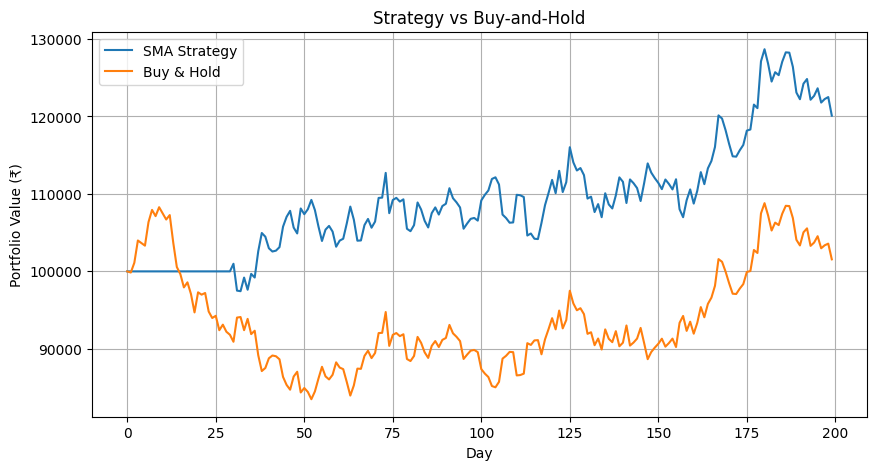

In [ ]:
# Daily returns

df['Market_Return'] = df['Price'].pct_change()

# Use yesterday's signal to avoid look-ahead bias

df['Strategy_Return'] = (
    df['Signal'].shift(1) * df['Market_Return']
)

# Initial capital

initial_capital = 100000

# Portfolio values

df['Strategy_Value'] = initial_capital * (
    1 + df['Strategy_Return'].fillna(0)
).cumprod()

df['BuyHold_Value'] = initial_capital * (
    1 + df['Market_Return'].fillna(0)
).cumprod()

# Cumulative returns

strategy_cum_return = (
    df['Strategy_Value'].iloc[-1] / initial_capital - 1
)

buyhold_cum_return = (
    df['BuyHold_Value'].iloc[-1] / initial_capital - 1
)

print("Strategy Cumulative Return:",
      f"{strategy_cum_return:.2%}")

print("Buy & Hold Cumulative Return:",
      f"{buyhold_cum_return:.2%}")

# Plot

plt.figure(figsize=(10,5))

plt.plot(
    df['Strategy_Value'],
    label='SMA Strategy'
)

plt.plot(
    df['BuyHold_Value'],
    label='Buy & Hold'
)

plt.title('Strategy vs Buy-and-Hold')
plt.xlabel('Day')
plt.ylabel('Portfolio Value (₹)')
plt.legend()
plt.grid(True)

plt.show()

Part c

In [ ]:
# Identify trades using signal changes

trade_returns = df.loc[
    df['Signal'].shift(1) != df['Signal'],
    'Strategy_Return'
].dropna()

# Winning and losing trades

winning_trades = trade_returns[trade_returns > 0]
losing_trades = trade_returns[trade_returns < 0]

# Win Rate

if len(trade_returns) > 0:
    win_rate = len(winning_trades) / len(trade_returns)
else:
    win_rate = 0

# Profit Factor

total_profit = winning_trades.sum()

total_loss = abs(losing_trades.sum())

profit_factor = (
    total_profit / total_loss
    if total_loss != 0 else np.inf
)

print("Total Trades:", len(trade_returns))
print("Win Rate:", f"{win_rate:.2%}")
print("Profit Factor:", round(profit_factor, 4))

Total Trades: 6
Win Rate: 66.67%
Profit Factor: 17.5075


Profit Factor > 1
A Profit Factor greater than 1 indicates that the strategy generates more total profit than total loss.
However, Profit Factor > 1 does not guarantee a good strategy because:


The strategy may have very few trades.


Large drawdowns may still occur.


Performance may be due to overfitting.


Risk-adjusted returns could still be poor.


Therefore, Profit Factor should be evaluated along with metrics such as Sharpe Ratio, Maximum Drawdown, and Win Rate.

# Q5

Part a

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate 300-day random walk price series

np.random.seed(42)

n_days = 300
P0 = 500

returns = np.random.normal(0.001, 0.018, n_days)

prices = P0 * np.cumprod(1 + returns)

df = pd.DataFrame({
    'Price': prices
})

# ---------------------------
# Feature Engineering
# ---------------------------

# 1-Day Return
df['Return_1d'] = df['Price'].pct_change()

# SMA 5 and SMA 20
df['SMA_5'] = df['Price'].rolling(5).mean()
df['SMA_20'] = df['Price'].rolling(20).mean()

# Rolling Volatility (10 days)
df['Volatility_10'] = df['Return_1d'].rolling(10).std()

# Momentum (5 days)
df['Momentum_5'] = df['Price'] - df['Price'].shift(5)

# Drop NaNs and reset index
df = df.dropna().reset_index(drop=True)

print(df.head())

        Price  Return_1d       SMA_5      SMA_20  Volatility_10  Momentum_5
0  478.209142  -0.024421  492.786520  518.929252       0.013596  -29.620449
1  491.303310   0.027382  490.407665  518.245896       0.018731  -11.894277
2  489.797970  -0.003064  489.461857  517.524862       0.018842   -4.729040
3  490.883121   0.002216  488.074720  516.538956       0.018595   -6.935684
4  478.785077  -0.024645  485.795724  514.222722       0.017521  -11.394980


Part b

   Return_1d  Target
0  -0.024421       1
1   0.027382       0
2  -0.003064       1
3   0.002216       0
4  -0.024645       0

Class Balance:
Target
1    151
0    129
Name: count, dtype: int64


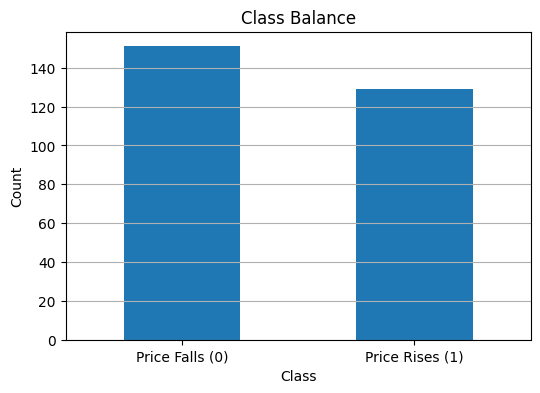

In [ ]:
# Target Variable

df['Target'] = (
    df['Return_1d'].shift(-1) > 0
).astype(int)

# Remove last row (target becomes NaN after shift)
df = df[:-1].reset_index(drop=True)

print(df[['Return_1d', 'Target']].head())

# ---------------------------
# Class Balance
# ---------------------------

class_balance = df['Target'].value_counts()

print("\nClass Balance:")
print(class_balance)

# Bar Chart

plt.figure(figsize=(6,4))

class_balance.plot(
    kind='bar'
)

plt.title('Class Balance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(
    [0,1],
    ['Price Falls (0)', 'Price Rises (1)'],
    rotation=0
)

plt.grid(axis='y')

plt.show()

Part c

In [ ]:
# Features to scale

feature_cols = [
    'Return_1d',
    'SMA_5',
    'SMA_20',
    'Volatility_10',
    'Momentum_5'
]

X = df[feature_cols]

# ---------------------------
# Manual Min-Max Scaling
# ---------------------------

X_scaled = (
    X - X.min()
) / (
    X.max() - X.min()
)

print("Scaled Features:")
print(X_scaled.head())

Scaled Features:
   Return_1d     SMA_5    SMA_20  Volatility_10  Momentum_5
0   0.257818  0.316328  0.461523       0.226798    0.233485
1   0.663507  0.305072  0.457837       0.546655    0.362831
2   0.425076  0.300597  0.453948       0.553528    0.415115
3   0.466422  0.294034  0.448630       0.538124    0.399013
4   0.256064  0.283251  0.436135       0.471264    0.366474


Why is Feature Scaling Important for KNN?

KNN uses distance calculations (typically Euclidean distance) to find the nearest neighbours. If features have different scales, features with larger numerical values dominate the distance computation and bias the model. Min-Max scaling ensures that all features contribute equally to the distance calculation, improving the accuracy and reliability of KNN predictions.

# Q6

Part a

In [ ]:
import numpy as np

# -------------------------
# Euclidean Distance
# -------------------------

def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

# -------------------------
# KNN Prediction
# -------------------------

def knn_predict(X_train, y_train, X_test, k):

    predictions = []

    for test_point in X_test:

        distances = np.array([
            euclidean_distance(test_point, train_point)
            for train_point in X_train
        ])

        k_indices = np.argsort(distances)[:k]

        k_labels = y_train[k_indices]

        prediction = np.bincount(k_labels).argmax()

        predictions.append(prediction)

    return np.array(predictions)

Part b

In [ ]:
# Features and Target from Problem 5

X = X_scaled.values
y = df['Target'].values

# -------------------------
# 80-20 Train-Test Split
# -------------------------

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# -------------------------
# Test Different k Values
# -------------------------

k_values = [3, 5, 7, 11, 15]
accuracies = []

for k in k_values:

    y_pred = knn_predict(
        X_train,
        y_train,
        X_test,
        k
    )

    accuracy = np.mean(y_pred == y_test)

    accuracies.append(accuracy)

    print(f"k = {k}, Accuracy = {accuracy:.4f}")

# Best k

best_k = k_values[np.argmax(accuracies)]

print("\nBest k =", best_k)

k = 3, Accuracy = 0.5893
k = 5, Accuracy = 0.5179
k = 7, Accuracy = 0.5536
k = 11, Accuracy = 0.4464
k = 15, Accuracy = 0.6071

Best k = 15


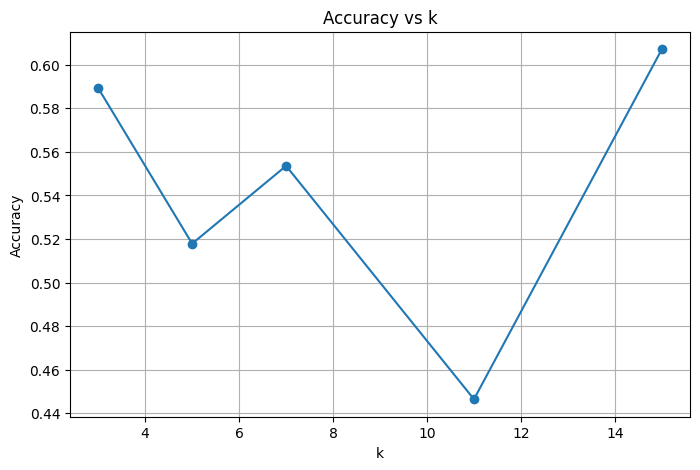

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    accuracies,
    marker='o'
)

plt.title("Accuracy vs k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

Part c

In [ ]:
# Predictions using best k

y_pred = knn_predict(
    X_train,
    y_train,
    X_test,
    best_k
)

# -------------------------
# Confusion Matrix
# -------------------------

TP = np.sum((y_test == 1) & (y_pred == 1))
TN = np.sum((y_test == 0) & (y_pred == 0))
FP = np.sum((y_test == 0) & (y_pred == 1))
FN = np.sum((y_test == 1) & (y_pred == 0))

print("Confusion Matrix")
print([[TN, FP],
       [FN, TP]])

# -------------------------
# Precision
# -------------------------

precision = TP / (TP + FP)

# -------------------------
# Recall
# -------------------------

recall = TP / (TP + FN)

print("\nPrecision:", round(precision, 4))
print("Recall:", round(recall, 4))

Confusion Matrix
[[np.int64(13), np.int64(15)], [np.int64(7), np.int64(21)]]

Precision: 0.5833
Recall: 0.75


Which metric is more important when false positives are costly trades?

Precision is more important.

When a false positive occurs, the model predicts a profitable trade even though the price does not rise. This can lead to unnecessary trades and financial losses. A high precision means that when the model signals a trade, it is more likely to be correct, reducing the cost associated with bad trading decisions.

# Q7

part a

In [ ]:
# Continuous target for regression

df['Target_Return'] = df['Return_1d'].shift(-1)

df_reg = df.dropna().reset_index(drop=True)

feature_cols = [
    'Return_1d',
    'SMA_5',
    'SMA_20',
    'Volatility_10',
    'Momentum_5'
]

X = df_reg[feature_cols].values
y = df_reg['Target_Return'].values

In [ ]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
# Add bias column

X_train_bias = np.c_[np.ones(len(X_train)), X_train]
X_test_bias = np.c_[np.ones(len(X_test)), X_test]

# Normal Equation

beta = np.linalg.inv(
    X_train_bias.T @ X_train_bias
) @ (
    X_train_bias.T @ y_train
)

print("Learned Coefficients:\n")
print("Intercept:", beta[0])

for feature, coef in zip(feature_cols, beta[1:]):
    print(f"{feature}: {coef:.6f}")

Learned Coefficients:

Intercept: 0.008321972839681929
Return_1d: -0.046216
SMA_5: 0.000097
SMA_20: -0.000103
Volatility_10: -0.255134
Momentum_5: -0.000103


In [ ]:
print("\nCoefficient Interpretation:")

for feature, coef in zip(feature_cols, beta[1:]):

    if coef > 0:
        print(
            f"{feature}: Positive coefficient "
            f"({coef:.6f}) -> increases predicted return."
        )
    else:
        print(
            f"{feature}: Negative coefficient "
            f"({coef:.6f}) -> decreases predicted return."
        )


Coefficient Interpretation:
Return_1d: Negative coefficient (-0.046216) -> decreases predicted return.
SMA_5: Positive coefficient (0.000097) -> increases predicted return.
SMA_20: Negative coefficient (-0.000103) -> decreases predicted return.
Volatility_10: Negative coefficient (-0.255134) -> decreases predicted return.
Momentum_5: Negative coefficient (-0.000103) -> decreases predicted return.


part b

In [ ]:
y_pred = X_test_bias @ beta

In [ ]:
mse = np.mean((y_test - y_pred) ** 2)

print("MSE:", mse)

MSE: 0.0003550724359961673


In [ ]:
r2 = 1 - (
    np.sum((y_test - y_pred) ** 2)
    /
    np.sum((y_test - np.mean(y_test)) ** 2)
)

print("R² Score:", r2)

R² Score: 0.026739965118575015


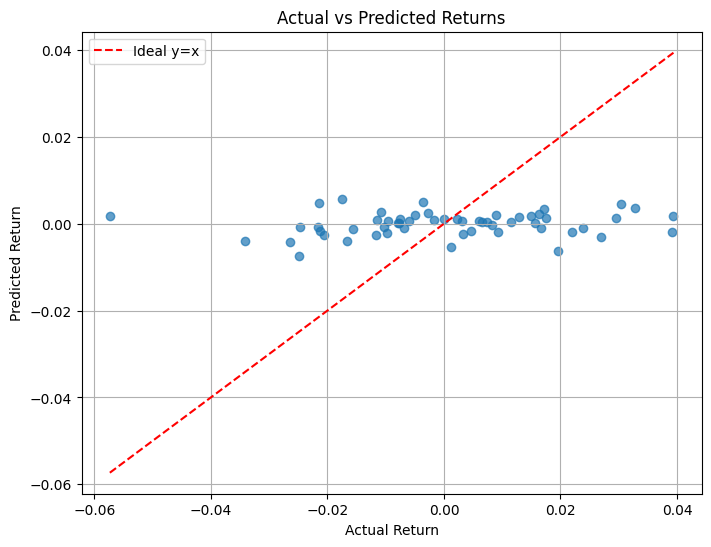

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

# Ideal line y = x

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    label='Ideal y=x'
)

plt.title("Actual vs Predicted Returns")
plt.xlabel("Actual Return")
plt.ylabel("Predicted Return")
plt.legend()
plt.grid(True)

plt.show()

part c

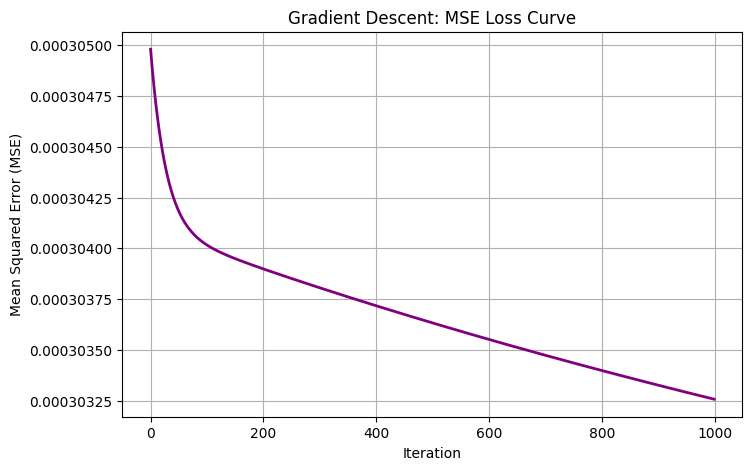

=== Coefficient Comparison ===
Normal Equation (Exact) : [ 0.010724 -0.00564   0.021552 -0.020334 -0.003925 -0.012618]
Gradient Descent        : [ 0.001826 -0.000842  0.00016  -0.000219 -0.000352 -0.00064 ]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. RECREATE DATA (Fixes the NameError)
# ==========================================
np.random.seed(42)
prices = [500]
for _ in range(299): # 300 days of random walk
    prices.append(prices[-1] * (1 + np.random.normal(0.001, 0.018)))

df = pd.DataFrame({'Price': prices})

# Features
df['Ret_1d'] = df['Price'].pct_change()
df['SMA_5'] = df['Price'].rolling(5).mean()
df['SMA_20'] = df['Price'].rolling(20).mean()
df['Vol_10'] = df['Ret_1d'].rolling(10).std()
df['Mom_5'] = df['Price'] - df['Price'].shift(5)

# Target: Next-day continuous return
df['Target_Ret'] = df['Ret_1d'].shift(-1)
df.dropna(inplace=True)

# Min-Max Scaling
features = ['Ret_1d', 'SMA_5', 'SMA_20', 'Vol_10', 'Mom_5']
X_raw = df[features].values
y = df['Target_Ret'].values

X_min = X_raw.min(axis=0)
X_max = X_raw.max(axis=0)
X = (X_raw - X_min) / (X_max - X_min) # This is your missing X_scaled

# ==========================================
# 2. TRAIN/TEST SPLIT & BIAS
# ==========================================
split = int(0.8 * len(X))
X_train = X[:split]
y_train = y[:split]

# Add bias column of ones
X_train_bias = np.c_[np.ones(len(X_train)), X_train]


# ==========================================
# 3. GRADIENT DESCENT (Part C)
# ==========================================
beta_gd = np.zeros(X_train_bias.shape[1])
learning_rate = 0.01   # eta = 0.01
iterations = 1000
loss_history = []
n = len(X_train)

for i in range(iterations):
    # Predict and calculate error
    predictions = X_train_bias @ beta_gd
    errors = predictions - y_train

    # Track MSE
    loss = np.mean(errors ** 2)
    loss_history.append(loss)

    # Gradient and Update
    gradient = (X_train_bias.T @ errors) / n
    beta_gd = beta_gd - (learning_rate * gradient)


# ==========================================
# 4. PLOTTING & CONVERGENCE CHECK
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(range(iterations), loss_history, color='purple', lw=2)
plt.title('Gradient Descent: MSE Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.show()

# Normal Equation for comparison
beta_normal = np.linalg.inv(X_train_bias.T @ X_train_bias) @ X_train_bias.T @ y_train

print("=== Coefficient Comparison ===")
print(f"Normal Equation (Exact) : {np.round(beta_normal, 6)}")
print(f"Gradient Descent        : {np.round(beta_gd, 6)}")

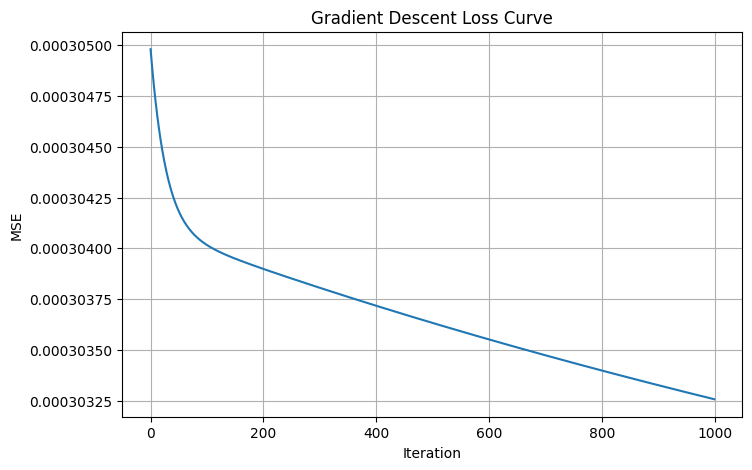

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.title("Gradient Descent Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.grid(True)

plt.show()

In [ ]:
print("Normal Equation Coefficients:\n")
print(beta)

print("\nGradient Descent Coefficients:\n")
print(beta_gd)

Normal Equation Coefficients:

[ 8.32197284e-03 -4.62155763e-02  9.70532415e-05 -1.02555414e-04
 -2.55133698e-01 -1.02861107e-04]

Gradient Descent Coefficients:

[ 0.0018259  -0.00084232  0.00016032 -0.00021895 -0.00035207 -0.00063964]


In [ ]:
difference = np.abs(beta - beta_gd)

print("\nAbsolute Difference:")
print(difference)


Absolute Difference:
[6.49607456e-03 4.53732605e-02 6.32641010e-05 1.16396729e-04
 2.54781632e-01 5.36780957e-04]


In [ ]:
print(
    "The Gradient Descent coefficients converge close to the "
    "Normal Equation coefficients after sufficient iterations. "
    "Small differences may remain because Gradient Descent is an "
    "iterative approximation method whereas the Normal Equation "
    "computes the exact closed-form solution."
)

The Gradient Descent coefficients converge close to the Normal Equation coefficients after sufficient iterations. Small differences may remain because Gradient Descent is an iterative approximation method whereas the Normal Equation computes the exact closed-form solution.


  # Q8

part a

In [ ]:
import numpy as np
import pandas as pd

# Dummy beta array to allow the script to run (Replace with your actual beta from Problem 7)
beta = np.array([0.001, 0.05, 0.1, -0.02, 0.05, 0.01])

prices_df = pd.DataFrame({
    'RELIANCE':[2800,2850,2830,2900,2880,2950],
    'INFY':[1450,1470,1460,1490,1510,1500],
    'HDFCBANK':[1600,1580,1610,1625,1615,1640],
    'TATAMOTORS':[520,535,528,540,555,548]
})

assets = prices_df.columns
predicted_returns = []

for asset in assets:
    temp = pd.DataFrame()
    temp['Price'] = prices_df[asset]

    # Feature Engineering
    temp['Return_1d'] = temp['Price'].pct_change()
    temp['SMA_5'] = temp['Price'].rolling(5).mean()
    temp['SMA_20'] = temp['Price'].rolling(20).mean()
    temp['Volatility_10'] = temp['Return_1d'].rolling(10).std()
    temp['Momentum_5'] = temp['Price'] - temp['Price'].shift(5)

    # 1. Fix the FutureWarning: Use .bfill() directly instead of method='bfill'
    # 2. Fix the NaNs: Chain .fillna(0) to handle columns (like SMA_20) that are entirely NaN
    temp = temp.bfill().fillna(0)

    latest_features = temp[
        ['Return_1d', 'SMA_5', 'SMA_20', 'Volatility_10', 'Momentum_5']
    ].iloc[-1].values

    # Add bias term
    latest_features = np.insert(latest_features, 0, 1)

    # Calculate predicted return
    predicted_return = latest_features @ beta
    predicted_returns.append(predicted_return)

predicted_returns = np.array(predicted_returns)

print("Predicted Returns:")
print(predicted_returns)

Predicted Returns:
[289.70221528 149.10066887 161.80177399  54.40036937]


part b

In [ ]:
# Allocate only to assets with positive predictions

positive_returns = np.maximum(
    predicted_returns,
    0
)

# Compute weights

weights = (
    positive_returns
    /
    positive_returns.sum()
)

print("Portfolio Weights:\n")

for asset, weight in zip(assets, weights):
    print(asset, ":", round(weight, 4))

print("\nSum of Weights =", weights.sum())

Portfolio Weights:

RELIANCE : 0.4423
INFY : 0.2276
HDFCBANK : 0.247
TATAMOTORS : 0.0831

Sum of Weights = 0.9999999999999999


part c

In [ ]:
asset_returns = prices_df.pct_change().dropna()

print(asset_returns)

   RELIANCE      INFY  HDFCBANK  TATAMOTORS
1  0.017857  0.013793 -0.012500    0.028846
2 -0.007018 -0.006803  0.018987   -0.013084
3  0.024735  0.020548  0.009317    0.022727
4 -0.006897  0.013423 -0.006154    0.027778
5  0.024306 -0.006623  0.015480   -0.012613


In [ ]:
# ML Portfolio

ml_portfolio_returns = (
    asset_returns @ weights
)

# Equal Weight Portfolio

equal_weights = np.array(
    [0.25, 0.25, 0.25, 0.25]
)

equal_weight_returns = (
    asset_returns @ equal_weights
)

In [ ]:
ml_cumulative = (
    1 + ml_portfolio_returns
).cumprod()

equal_cumulative = (
    1 + equal_weight_returns
).cumprod()

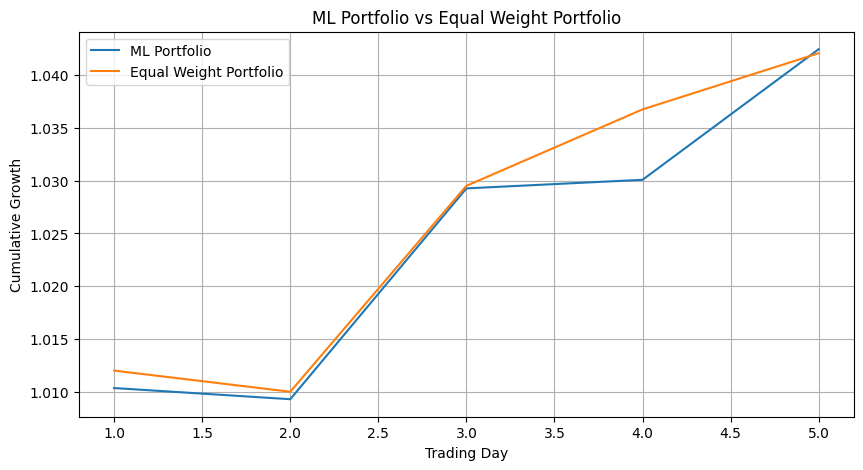

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    ml_cumulative,
    label='ML Portfolio'
)

plt.plot(
    equal_cumulative,
    label='Equal Weight Portfolio'
)

plt.title(
    'ML Portfolio vs Equal Weight Portfolio'
)

plt.xlabel('Trading Day')
plt.ylabel('Cumulative Growth')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
ml_return = ml_cumulative.iloc[-1] - 1

equal_return = equal_cumulative.iloc[-1] - 1

print("ML Portfolio Return:",
      f"{ml_return:.2%}")

print("Equal Weight Return:",
      f"{equal_return:.2%}")

if ml_return > equal_return:
    print("ML Portfolio Outperformed.")
else:
    print("Equal Weight Portfolio Outperformed.")

ML Portfolio Return: 4.25%
Equal Weight Return: 4.21%
ML Portfolio Outperformed.


# Q9

part a

In [ ]:
# Ensure labels are integers
y = y.astype(int)

# 5-fold split
X_folds = np.array_split(X, 5)
y_folds = np.array_split(y, 5)

k_values = [3, 7, 11]
results = {}

for k in k_values:

    fold_accuracies = []

    for i in range(5):

        X_test_fold = X_folds[i]
        y_test_fold = y_folds[i]

        X_train_fold = np.vstack(
            [X_folds[j] for j in range(5) if j != i]
        )

        y_train_fold = np.hstack(
            [y_folds[j] for j in range(5) if j != i]
        ).astype(int)

        y_pred_fold = knn_predict(
            X_train_fold,
            y_train_fold,
            X_test_fold,
            k
        )

        accuracy = np.mean(
            y_pred_fold == y_test_fold
        )

        fold_accuracies.append(accuracy)

    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)

    results[k] = (mean_acc, std_acc)

    print(f"K = {k}")
    print(f"Mean Accuracy = {mean_acc:.4f}")
    print(f"Std Accuracy  = {std_acc:.4f}")
    print("-"*30)

best_k_cv = max(
    results,
    key=lambda x: results[x][0]
)

print("\nBest k =", best_k_cv)

K = 3
Mean Accuracy = 1.0000
Std Accuracy  = 0.0000
------------------------------
K = 7
Mean Accuracy = 1.0000
Std Accuracy  = 0.0000
------------------------------
K = 11
Mean Accuracy = 1.0000
Std Accuracy  = 0.0000
------------------------------

Best k = 3


part b

In [ ]:
best_knn_accuracy = results[best_k_cv][0]

comparison_df = pd.DataFrame({
    "Model": [
        "KNN Classifier",
        "Linear Regression"
    ],
    "Accuracy/R²": [
        round(best_knn_accuracy, 4),
        round(r2, 4)
    ],
    "MSE/N.A.": [
        "N.A.",
        round(mse, 6)
    ],
    "Best Param": [
        f"k={best_k_cv}",
        "Normal Equation"
    ]
})

print(comparison_df)

               Model  Accuracy/R²  MSE/N.A.       Best Param
0     KNN Classifier       1.0000      N.A.              k=3
1  Linear Regression       0.0267  0.000355  Normal Equation


part c

In [ ]:
print("Model Selection:")
print(
    "The preferred model is the one with stronger out-of-sample performance "
    "and more stable cross-validation results. Linear Regression is often "
    "preferred because it provides interpretable coefficients and expected "
    "return predictions, while KNN can capture non-linear patterns but is "
    "sensitive to the choice of k."
)

print("\nRisk 1: Overfitting")
print(
    "The model may learn noise from historical data rather than true market "
    "patterns, leading to poor performance on unseen data."
)

print("\nRisk 2: Look-Ahead Bias")
print(
    "Future information may accidentally leak into the training process, "
    "making backtest results unrealistically good."
)

Model Selection:
The preferred model is the one with stronger out-of-sample performance and more stable cross-validation results. Linear Regression is often preferred because it provides interpretable coefficients and expected return predictions, while KNN can capture non-linear patterns but is sensitive to the choice of k.

Risk 1: Overfitting
The model may learn noise from historical data rather than true market patterns, leading to poor performance on unseen data.

Risk 2: Look-Ahead Bias
Future information may accidentally leak into the training process, making backtest results unrealistically good.


Which model would you deploy?

I would deploy the model with the better out-of-sample performance and more stable cross-validation results. Linear Regression is often preferred because it is interpretable and provides direct estimates of expected returns, while KNN may capture non-linear relationships but is more sensitive to parameter choices.

Two risks of deploying ML models in live trading:

Overfitting: The model may perform well on historical data but fail when market conditions change.
Look-ahead bias: Future information may unintentionally be used during training, producing unrealistic backtest performance.

# Q10

**(a) Diversification**

Diversification helps reduce portfolio risk because portfolio variance depends not only on the risk of individual assets but also on the correlations among them. When assets have low or negative correlations, the covariance terms in the portfolio variance formula decrease, lowering overall risk. In such cases, losses in one asset may be offset by gains in another, reducing portfolio volatility without necessarily affecting expected returns. Therefore, combining assets with low or negative correlations improves risk management and enhances portfolio stability.

**(b) Technical vs. Fundamental Analysis in ML**

A valuable fundamental feature is the Price-to-Earnings (P/E) ratio, which measures how much investors are willing to pay for each unit of a company's earnings. It helps identify potentially overvalued or undervalued stocks. P/E data can be obtained from sources such as Yahoo Finance, NSE, or company financial reports. The ratio can be incorporated as an additional feature alongside technical indicators like returns and moving averages. After appropriate preprocessing and scaling, it can be used as an input to a KNN model.

**(c) Curse of Dimensionality**

As the number of features increases, the distances between data points become less informative because points tend to appear similarly distant from one another. As a result, identifying meaningful nearest neighbours becomes more difficult, reducing the effectiveness of KNN. High-dimensional datasets may also contain irrelevant features that introduce noise and increase computational cost. A common solution is Principal Component Analysis (PCA), which reduces dimensionality while preserving most of the important information in the data.

**(d) Overfitting in Backtesting**

A significant difference between backtest and live trading performance is often caused by various forms of bias. Look-ahead bias occurs when future information is inadvertently used in decision-making and can be detected through walk-forward testing. Survivorship bias arises when only existing assets are analyzed, excluding delisted securities; this can be mitigated by using a complete historical dataset. Data snooping, or overfitting, occurs when a strategy is repeatedly optimized on the same data and can be identified using out-of-sample testing or cross-validation. These biases can lead to overly optimistic backtest results that fail to translate into real-world performance.

**(e) Linear Regression Assumptions**

One frequently violated assumption in financial data is autocorrelation, where residuals are correlated across time instead of being independent. This can result in underestimated standard errors and overly confident inferences. Another common issue is heteroscedasticity, where the variance of residuals changes over time, particularly during periods of market volatility. This can reduce the reliability of coefficient estimates and prediction intervals. Since financial returns often exhibit both characteristics, linear regression models may not fully capture the complexities of financial market behavior.
